In [1]:
import sys
sys.path.append("../")

from brian2 import *
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

from aqua.plotting_functions import *
from aqua.utils import *

from functions import *


In [2]:

"""- - - - MAIN SIMULATION - - - - """

T = 2000 # ms
N_trials = 100
N_spikes = 40
spike_delay = 4*ms

# gamma params
N_neurons = 2
k_stages = 3
N_relay = N_neurons * k_stages          # number of relay neurons
N_syn = N_neurons * (k_stages - 1)      # number of internal synapses
theta = 1.5*ms
#gain = 1/theta*second      # scale the gain to have on avg 1 output spike per input spike
#print(gain)

# keep count of spikes from dist
counts = np.zeros(N_trials)

spike_delays = []

for l in tqdm(range(N_trials)):
    # 1. Setup Input (Presynaptic Neuron)
    # Let's say it fires at 20Hz
    #P = PoissonGroup(1, 20*Hz)
    idx = np.array([np.zeros(N_spikes), np.ones(N_spikes)]).flatten()
    spike_times = np.linspace(10, 3*T/4, N_spikes)
    spike_arr = np.array([spike_times, spike_times]).flatten()*ms
    spike_times = spike_times * ms
    ms_per_spike = (T/2 - 10)/N_spikes
    firing_frequency = 1000/ms_per_spike
    #print(f"FF: {firing_frequency}")
    P = SpikeGeneratorGroup(N_neurons, idx, spike_arr)

    #RATE = 1.0/theta
    #print(f"RATE: {RATE}")
    #print(f"ODDS: {RATE * defaultclock.dt}")

    # 2. The GAMMA Generator Group - k poisson generators linked
    Relay = NeuronGroup(N_relay, 
        '''
        rate = 1.0/theta : Hz  # rate is fixed
        is_active : 1
        ''',
        threshold = 'is_active > 0 and rand() < rate * dt',
        reset = 'is_active -= 1', 
        method = 'euler')

    Relay.is_active = False
    # connect relay neurons internally
    S_internal = Synapses(Relay, Relay, on_pre = '''is_active += 1''')
    #S_internal.connect(i = np.arange(k_stages-1), j = np.arange(1, k_stages))       # connect neuron to the next one in line
    i_origin = np.arange(0, N_syn, 1)
    j_target = i_origin + k_stages - 1
    S_internal.connect(i = i_origin, j = j_target)

    # 3. Connect Pre-synapse to the Generator
    # Each spike from P increases the firing rate of PoissonGen
    S_in = Synapses(P, Relay, on_pre='is_active += 1')
    S_in.connect(condition = 'i == j')      # connect pre- to first in relay

    # 4. Connect Generator to Post-synaptic Target
    Post = NeuronGroup(N_neurons, 'dv/dt = -v/(10*ms) : 1', threshold='v>1', reset='v=0')
    S_out = Synapses(Relay, Post, on_pre='v_post += 0.3')
    i_out = np.arange(N_syn, N_relay, 1)
    j_out = i_out - N_syn
    S_out.connect(i = i_out, j = j_out)

    # Monitors
    mon_p = SpikeMonitor(P)
    mon_gen = SpikeMonitor(Relay, record = True)
    mon_active = StateMonitor(Relay, 'is_active', record = True)
    mon_post = StateMonitor(Post, 'v', record = True)
    spikemon_post = SpikeMonitor(Post, record = True)

    
    run(T*ms)

    spk_trn = mon_gen.spike_trains()[N_relay-1]    # get the spike train of the last relay neuron
    #print(spk_trn)

    counts[l] = len(spk_trn)


    for spike in spk_trn:
        #print(spike)
        delay = spike - spike_times[spike_times < spike][-1]    #last spike before the poisson spike
        #print(delay)
        spike_delays.append(delay*1000)

    


100%|██████████| 100/100 [01:29<00:00,  1.12it/s]


In [3]:
print(mon_p.spike_trains())

{0: array([0.01  , 0.0482, 0.0864, 0.1246, 0.1628, 0.201 , 0.2392, 0.2774,
       0.3156, 0.3538, 0.392 , 0.4302, 0.4684, 0.5066, 0.5448, 0.583 ,
       0.6212, 0.6594, 0.6976, 0.7358, 0.7741, 0.8123, 0.8505, 0.8887,
       0.9269, 0.9651, 1.0033, 1.0415, 1.0797, 1.1179, 1.1561, 1.1943,
       1.2325, 1.2707, 1.3089, 1.3471, 1.3853, 1.4235, 1.4617, 1.5   ]) * second, 1: array([0.01  , 0.0482, 0.0864, 0.1246, 0.1628, 0.201 , 0.2392, 0.2774,
       0.3156, 0.3538, 0.392 , 0.4302, 0.4684, 0.5066, 0.5448, 0.583 ,
       0.6212, 0.6594, 0.6976, 0.7358, 0.7741, 0.8123, 0.8505, 0.8887,
       0.9269, 0.9651, 1.0033, 1.0415, 1.0797, 1.1179, 1.1561, 1.1943,
       1.2325, 1.2707, 1.3089, 1.3471, 1.3853, 1.4235, 1.4617, 1.5   ]) * second}


[0.01       0.04820513 0.08641026 0.12461538 0.16282051 0.20102564
 0.23923077 0.2774359  0.31564103 0.35384615 0.39205128 0.43025641
 0.46846154 0.50666667 0.54487179 0.58307692 0.62128205 0.65948718
 0.69769231 0.73589744 0.77410256 0.81230769 0.85051282 0.88871795
 0.92692308 0.96512821 1.00333333 1.04153846 1.07974359 1.11794872
 1.15615385 1.19435897 1.2325641  1.27076923 1.30897436 1.34717949
 1.38538462 1.42358974 1.46179487 1.5       ] s
[  10.           48.20512821   86.41025641  124.61538462  162.82051282
  201.02564103  239.23076923  277.43589744  315.64102564  353.84615385
  392.05128205  430.25641026  468.46153846  506.66666667  544.87179487
  583.07692308  621.28205128  659.48717949  697.69230769  735.8974359
  774.1025641   812.30769231  850.51282051  888.71794872  926.92307692
  965.12820513 1003.33333333 1041.53846154 1079.74358974 1117.94871795
 1156.15384615 1194.35897436 1232.56410256 1270.76923077 1308.97435897
 1347.17948718 1385.38461538 1423.58974359 1461.794871

Text(0, 0.5, 'is_active [mV]')

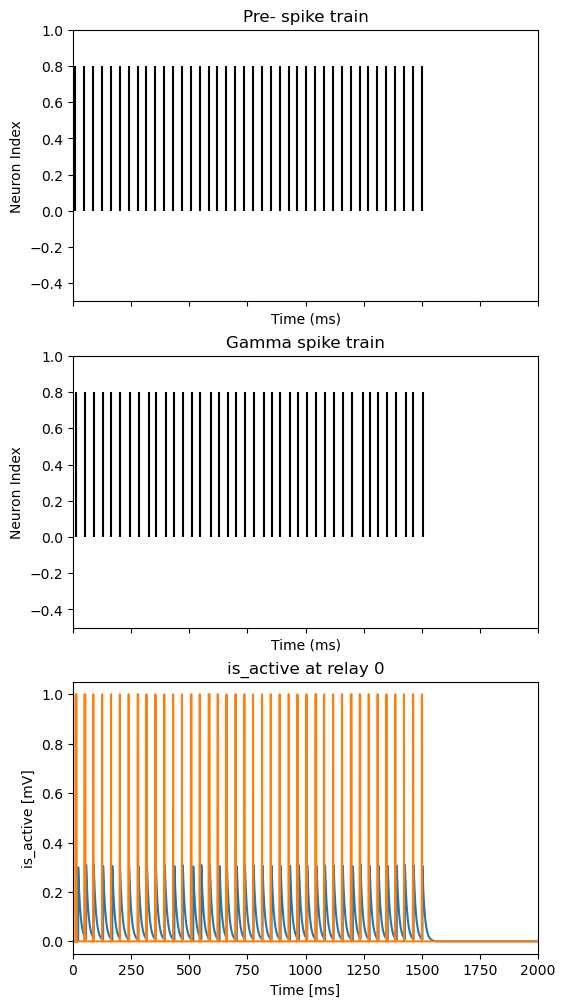

In [4]:
fig, ax = plt.subplots(3, 1, figsize = (6, 12), sharex = True)

print(spike_times)

plot_raster(np.array([spike_times/ms]), T, ax = ax[0])
ax[0].set_title("Pre- spike train")

plot_raster(np.array([spk_trn/ms]), T, ax = ax[1])
ax[1].set_title("Gamma spike train")

ax[2].plot(mon_post.t/ms, mon_post.v[0])
ax[2].set_title("Post- membrane potential")
ax[2].set_xlabel("Time [ms]")
ax[2].set_ylabel("v [mV]")

ax[2].plot(mon_active.t/ms, mon_active.is_active[0])
ax[2].set_title("is_active at relay 0")
ax[2].set_xlabel("Time [ms]")
ax[2].set_ylabel("is_active [mV]")

Mean: 40.0
STD: 0.0
Mean Ratio = 1.0
STD Ratio = 0.0


Text(0.5, 0, 'Time (ms)')

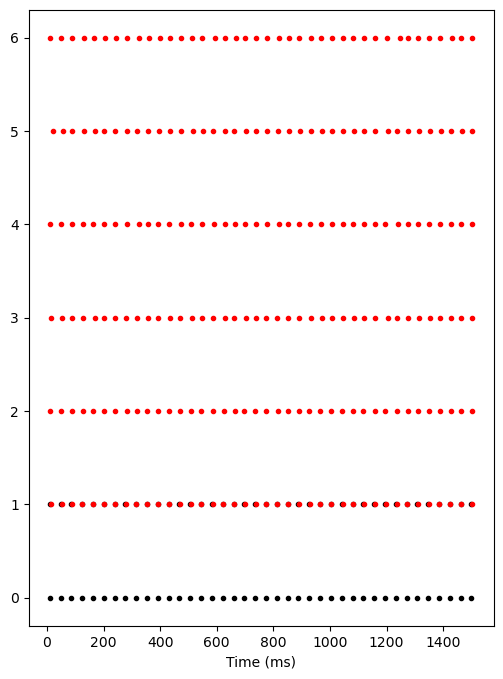

In [5]:
# Visualization of the frequency transformation

avg_poiss = np.mean(counts)
std_poiss = np.std(counts)
print(f"Mean: {avg_poiss}")
print(f"STD: {std_poiss}")
print(f"Mean Ratio = {avg_poiss/N_spikes}")
print(f"STD Ratio = {std_poiss/N_spikes}")

fig, ax = plt.subplots(1, 1, figsize = (6, 8), sharex = True)


ax.plot(mon_p.t/ms, mon_p.i, '.k', label='Pre-synaptic')
ax.plot(mon_gen.t/ms, mon_gen.i + 1, '.r', label='Poisson Gen')
ax.set_xlabel('Time (ms)')


3
1.5 ms


Text(0, 0.5, 'Time delay of synapse [ms]')

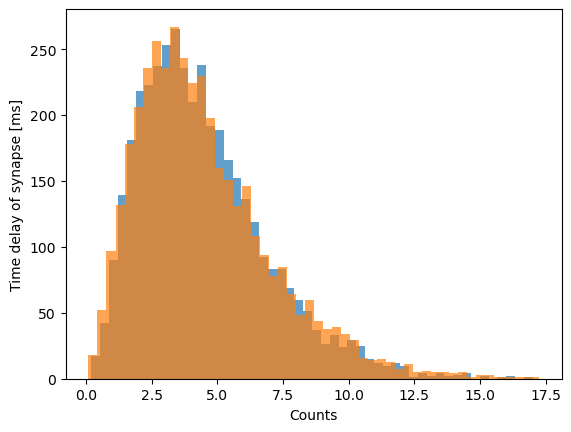

In [6]:
print(k_stages)
print(theta)
gamma_dist = 1000*np.random.gamma(k_stages, theta, size = len(spike_delays))


plt.hist(spike_delays, bins = 50, alpha = 0.7)
plt.hist(gamma_dist, bins = 50, alpha = 0.7)
plt.xlabel("Counts")
plt.ylabel("Time delay of synapse [ms]")